1. Overall survival rate:
38.38383838383838

2. Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

3. Survival rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

4. Average age survivors vs non survivors:
Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

5. Average fare by class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64


/tmp/ipykernel_3454/2380780364.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Sex',y='Survived',palette='Set2')


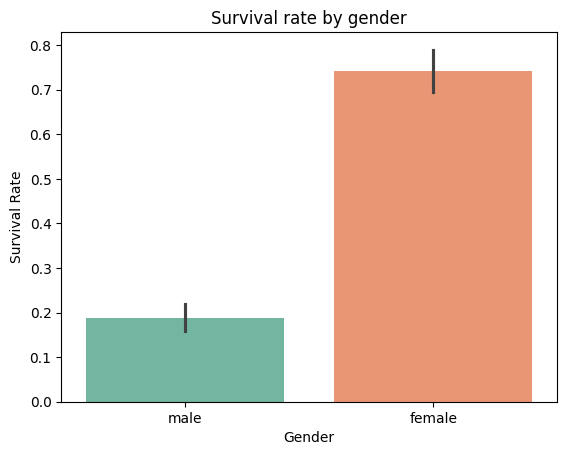

/tmp/ipykernel_3454/2380780364.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Pclass',y='Survived',palette='Set1')


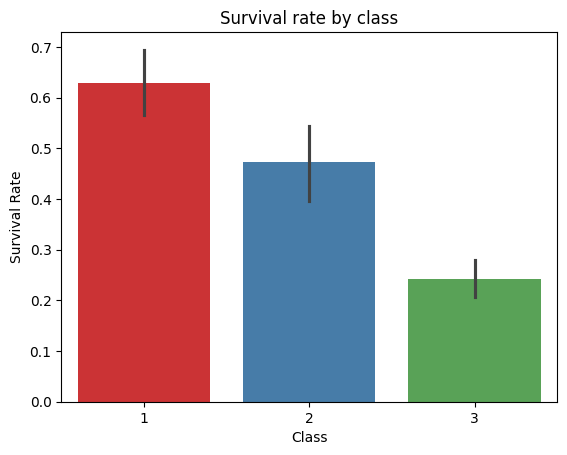

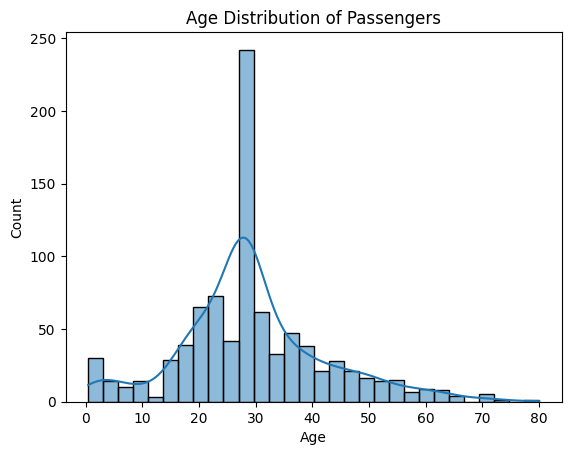

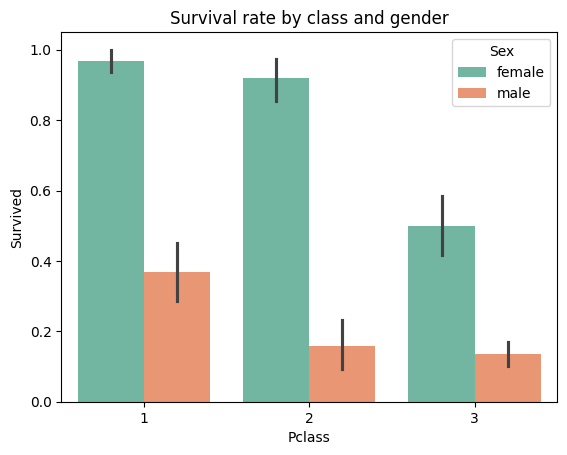

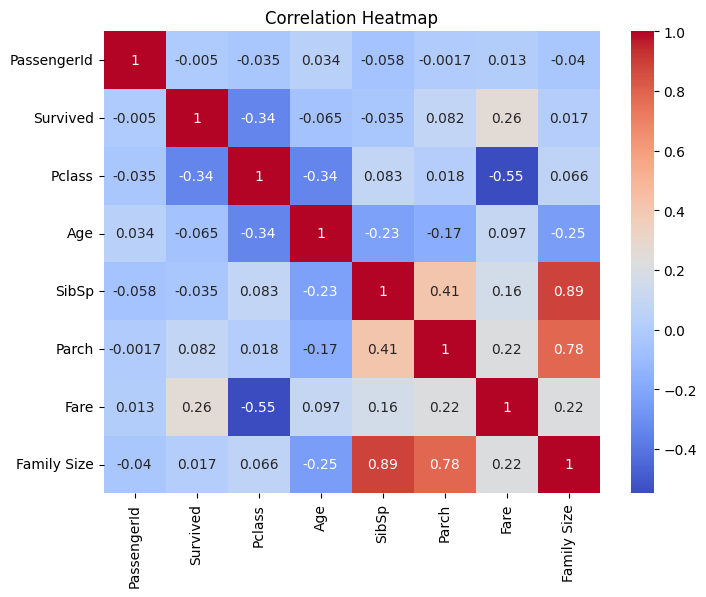

/tmp/ipykernel_3454/2380780364.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Pclass',y='Fare',palette='Set2')


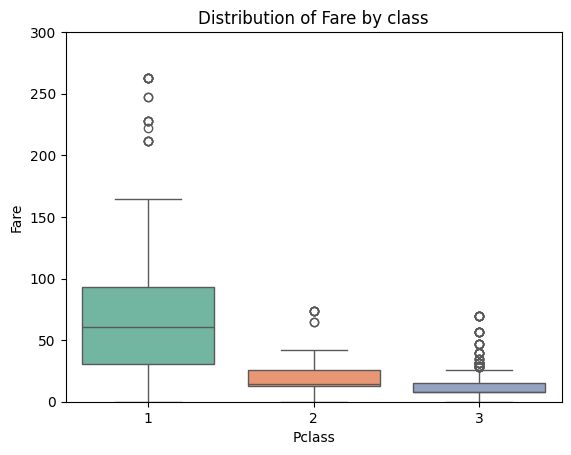

/tmp/ipykernel_3454/2380780364.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='IsAlone', y='Survived', palette='Set2')


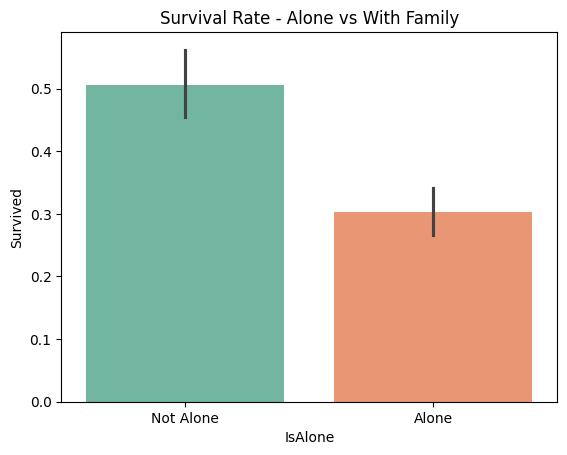

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Family Size']=df['SibSp']+df['Parch']+1
df['IsAlone'] = df['Family Size'].apply(
    lambda x: 'Alone' if x == 1 else 'Not Alone'
)

print("1. Overall survival rate:")
print(df['Survived'].mean() * 100)

print("\n2. Survival rate by gender:")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\n3. Survival rate by class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

print("\n4. Average age survivors vs non survivors:")
print(df.groupby('Survived')['Age'].mean())

print("\n5. Average fare by class:")
print(df.groupby('Pclass')['Fare'].mean())
print(df.groupby(['Pclass','Sex'])['Survived'].mean() * 100)


sns.barplot(data=df,x='Sex',y='Survived',palette='Set2')
plt.title('Survival rate by gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

sns.barplot(data=df,x='Pclass',y='Survived',palette='Set1')
plt.title('Survival rate by class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()

sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.show()

sns.barplot(data=df,x='Pclass',y='Survived',hue='Sex',palette='Set2')
plt.title('Survival rate by class and gender')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

sns.boxplot(data=df,x='Pclass',y='Fare',palette='Set2')
plt.title('Distribution of Fare by class')
plt.ylim(0,300)
plt.show()

sns.barplot(data=df, x='IsAlone', y='Survived', palette='Set2')
plt.title('Survival Rate - Alone vs With Family')
plt.show()